In [1]:
from flash_ansr import FlashANSR, SoftmaxSamplingConfig, FlashANSRDataset, get_path
from flash_ansr.utils.tensor_ops import pad_input_set
from flash_ansr.expressions.token_ops import identify_constants
from flash_ansr.expressions.compilation import codify

from collections import defaultdict
 
import torch
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from sklearn.decomposition import PCA
from sklearn.neighbors import KernelDensity

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
MODEL_NAMES = [
    "ansr-models/v23.0-3M",
    # "ansr-models/v23.0-20M",
    # "ansr-models/v23.0-120M",
    # "ansr-models/v23.0-1B",
]

In [3]:
models = {
    model_name: FlashANSR.load(directory=get_path('models', model_name), device=device)
    for model_name in MODEL_NAMES
}

In [4]:
dataset = FlashANSRDataset.from_config(get_path('configs', MODEL_NAMES[0].split('/')[1], 'dataset_train.yaml'))

Compiling Skeletons: 100%|██████████| 107/107 [00:00<00:00, 25108.57it/s]


In [5]:
N_SAMPLES = 2**17
print(f'{N_SAMPLES:,}')

131,072


In [2]:
import torch
from torch import nn
import torch.optim as optim

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

In [ ]:
model_pcas = {}

for model_name, model in models.items():
    embeddings = []
    for d in dataset.iterate(size=N_SAMPLES, verbose=True, persistent=True, n_per_equation=1, batch_size=1, preprocess=True, preprocess_in_worker=True):
        data_tensor = torch.cat([d['x_tensors'], d['y_tensors']], dim=-1)
        with torch.no_grad():
            embedding = model.flash_ansr_model._create_memory(data_tensor.to(device), d['data_attn_mask'].to(device))
            embeddings.append(embedding.cpu().numpy()[0])
    
    embeddings = np.array(embeddings)
    # model_pcas[model_name] = PCA(n_components=2)
    # model_pcas[model_name].fit(embeddings.reshape(embeddings.shape[0], -1))

    latent_dim = 2
    autoencoder = Autoencoder(input_dim=embeddings.shape[1], latent_dim=latent_dim)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)
    num_epochs = 50
    batch_size = 256
    dataset_tensor = torch.tensor(embeddings, dtype=torch.float32)
    dataloader = torch.utils.data.DataLoader(dataset_tensor, batch_size=batch_size, shuffle=True)
    for epoch in range(num_epochs):
        for batch in dataloader:
            optimizer.zero_grad()
            recon = autoencoder(batch)
            loss = criterion(recon, batch)
            loss.backward()
            optimizer.step()
        if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
    model_pcas[model_name] = autoencoder.encoder

/tmp/ipykernel_8971/3089716736.py:5: RuntimeWarning: worker preprocessing requested but no preprocessor configured; falling back to main process.
  for d in dataset.iterate(size=N_SAMPLES, verbose=True, persistent=True, n_per_equation=1, batch_size=1, preprocess=True, preprocess_in_worker=True):
Generating Batches: 100%|██████████| 131072/131072 [05:51<00:00, 373.08it/s]


# Examples 1

In [ ]:
test_examples = [
    {'expression': 'inv(1 + (x - 1)**2 / 1)', 'x_range': (0, 10), 'n_samples': 256, 'constants': [1, 0, 1], 'test_data': None, 'embeddings': defaultdict(list), 'embeddings_pca': defaultdict(list), 'latex': r'\frac{1}{1 + x^2}'},
    {'expression': 'exp(neg((x - 1)**2 / 1))', 'x_range': (0, 10), 'n_samples': 256, 'constants': [0, 1], 'test_data': None, 'embeddings': defaultdict(list), 'embeddings_pca': defaultdict(list), 'latex': r'e^{-x^2}'},
    {'expression': '1 * sin(x / 1 + 0)', 'x_range': (1, 10), 'n_samples': 256, 'constants': [1, 1, 0], 'test_data': None, 'embeddings': defaultdict(list), 'embeddings_pca': defaultdict(list), 'latex': r'\sin(x)'},
    {'expression': 'log(x / 1 + 0)', 'x_range': (1, 10), 'n_samples': 256, 'constants': [1, 0], 'test_data': None, 'embeddings': defaultdict(list), 'embeddings_pca': defaultdict(list), 'latex': r'\log x'},

]

In [ ]:
N_PER_FUNCTION = 2**13

for example in test_examples:
    for _ in tqdm(range(N_PER_FUNCTION)):
        parsed_expression = model.simplipy_engine.parse(example['expression'], mask_numbers=True)
        executable_prefix_expression = model.simplipy_engine.operators_to_realizations(parsed_expression)
        prefix_expression_with_constants, constants_names = identify_constants(executable_prefix_expression, inplace=True)
        code_string = model.simplipy_engine.prefix_to_infix(prefix_expression_with_constants, realization=True)
        code = codify(code_string, ['x'] + constants_names)

        if example['constants'] is None:
            fn = lambda x: model.simplipy_engine.code_to_lambda(code)(x)
        else:
            fn = lambda x: model.simplipy_engine.code_to_lambda(code)(x, *example['constants'])

        x = np.random.uniform(example['x_range'][0], example['x_range'][1], example['n_samples'])
        x = x.reshape(-1, 1)

        y = fn(x)
        if isinstance(y, float):
            y = np.full_like(x, y)
            
        data_dict = {
            'x_tensors': pad_input_set(torch.tensor(x, dtype=torch.float32).unsqueeze(0), length=model.n_variables),
            'y_tensors': torch.tensor(y, dtype=torch.float32).unsqueeze(0),
        }

        data_tensor = torch.cat([data_dict['x_tensors'], data_dict['y_tensors']], dim=-1)
        attn_mask = torch.ones(data_tensor.shape[:-1], dtype=torch.bool)

        for model_name, model in models.items():
            with torch.no_grad():
                embedding = model.flash_ansr_model._create_memory(data_tensor.to(device), attn_mask.to(device))
                example['embeddings'][model_name].append(embedding.cpu().numpy()[0])
                embedding_pca = model_pcas[model_name].transform(embedding.cpu().numpy().reshape(1, -1))
                example['embeddings_pca'][model_name].append(embedding_pca[0])

for model_name in MODEL_NAMES:
    for example in test_examples:
        # example['embeddings'][model_name] = np.array(example['embeddings'][model_name])
        example['embeddings_pca'][model_name] = np.array(example['embeddings_pca'][model_name])

100%|██████████| 64/64 [00:01<00:00, 34.44it/s]


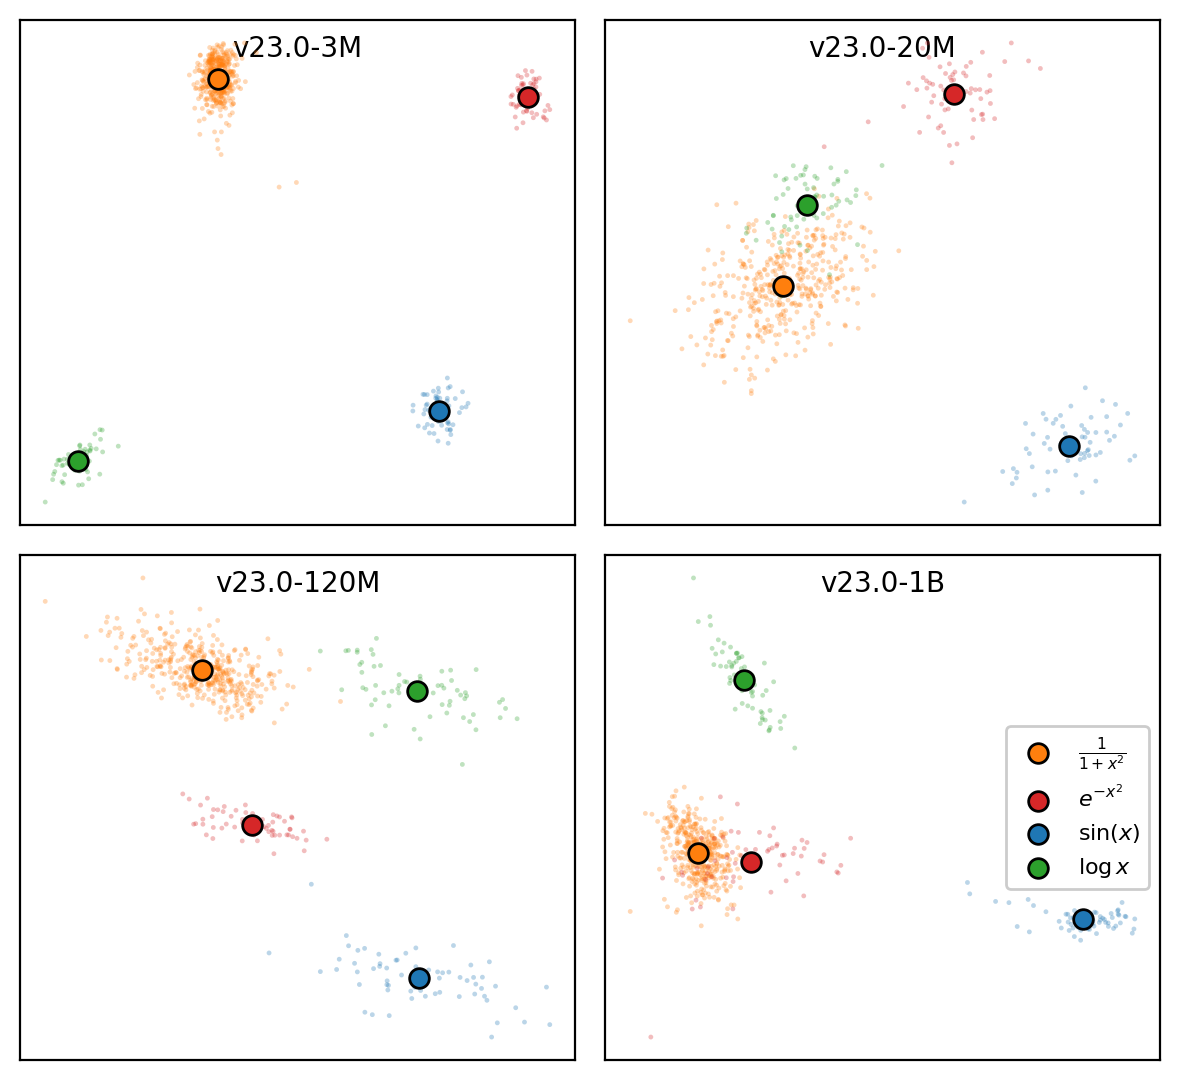

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(6, 5.5), dpi=200)

for i, (model_name, ax) in enumerate(zip(MODEL_NAMES, axes.flatten())):
    ax: plt.Axes
    for color, example in zip(['tab:orange', 'tab:red', 'tab:blue', 'tab:green'], test_examples):

        ax.scatter(
            example['embeddings_pca'][model_name][:, 0],
            example['embeddings_pca'][model_name][:, 1],
            alpha=0.3,
            color=color,
            s=3,
            zorder=4,
            edgecolors='none'
        )

        mean_point = example['embeddings_pca'][model_name].mean(axis=0)
        ax.scatter(
            mean_point[0],
            mean_point[1],
            alpha=1.0,
            color=color,
            s=50,
            zorder=5,
            marker='o',
            edgecolors='black',
            linewidths=1,
            label=f"${example['latex']}$"
        )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.annotate(f'{model_name.split("/")[-1]}', xy=(0.5, 0.97), xycoords='axes fraction', va='top', ha='center', fontsize=10)
    ax.grid(alpha=0.5)

axes.flatten()[-1].legend(
    loc='right',
    fontsize=8,
    framealpha=1.0,
)

fig.tight_layout()

# Examples 2

In [ ]:
test_examples_sigma = {
    'sigma': [
        {'expression': 'exp(neg((x - 1)**2 / 1))', 'x_range': (0, 10), 'n_samples': 256, 'constants': [0, 2], 'test_data': None, 'embeddings': defaultdict(list), 'embeddings_pca': defaultdict(list), 'latex': r'e^{-\frac{x^2}{2}}'},
        {'expression': 'exp(neg((x - 1)**2 / 1))', 'x_range': (0, 10), 'n_samples': 256, 'constants': [0, 1.5], 'test_data': None, 'embeddings': defaultdict(list), 'embeddings_pca': defaultdict(list), 'latex': r'e^{-\frac{x^2}{1.5}}'},
        {'expression': 'exp(neg((x - 1)**2 / 1))', 'x_range': (0, 10), 'n_samples': 256, 'constants': [0, 1.2], 'test_data': None, 'embeddings': defaultdict(list), 'embeddings_pca': defaultdict(list), 'latex': r'e^{-\frac{x^2}{1.2}}'},
        {'expression': 'exp(neg((x - 1)**2 / 1))', 'x_range': (0, 10), 'n_samples': 256, 'constants': [0, 1], 'test_data': None, 'embeddings': defaultdict(list), 'embeddings_pca': defaultdict(list), 'latex': r'e^{-x^2}'},
        {'expression': 'exp(neg((x - 1)**2 / 1))', 'x_range': (0, 10), 'n_samples': 256, 'constants': [0, 1/1.2], 'test_data': None, 'embeddings': defaultdict(list), 'embeddings_pca': defaultdict(list), 'latex': r'e^{-\frac{x^2}{0.83}}'},
        {'expression': 'exp(neg((x - 1)**2 / 1))', 'x_range': (0, 10), 'n_samples': 256, 'constants': [0, 1/1.5], 'test_data': None, 'embeddings': defaultdict(list), 'embeddings_pca': defaultdict(list), 'latex': r'e^{-\frac{x^2}{0.67}}'},
        {'expression': 'exp(neg((x - 1)**2 / 1))', 'x_range': (0, 10), 'n_samples': 256, 'constants': [0, 0.5], 'test_data': None, 'embeddings': defaultdict(list), 'embeddings_pca': defaultdict(list), 'latex': r'e^{-\frac{x^2}{0.5}}'}
    ]
}

In [ ]:
N_PER_FUNCTION = 2**13

for k, test_examples_set in test_examples_sigma.items():
    for example in tqdm(test_examples_set):
        for _ in range(N_PER_FUNCTION):
            parsed_expression = model.simplipy_engine.parse(example['expression'], mask_numbers=True)
            executable_prefix_expression = model.simplipy_engine.operators_to_realizations(parsed_expression)
            prefix_expression_with_constants, constants_names = identify_constants(executable_prefix_expression, inplace=True)
            code_string = model.simplipy_engine.prefix_to_infix(prefix_expression_with_constants, realization=True)
            code = codify(code_string, ['x'] + constants_names)

            if example['constants'] is None:
                fn = lambda x: model.simplipy_engine.code_to_lambda(code)(x)
            else:
                fn = lambda x: model.simplipy_engine.code_to_lambda(code)(x, *example['constants'])

            x = np.random.uniform(example['x_range'][0], example['x_range'][1], example['n_samples'])
            x = x.reshape(-1, 1)

            y = fn(x)
            if isinstance(y, float):
                y = np.full_like(x, y)
                
            data_dict = {
                'x_tensors': pad_input_set(torch.tensor(x, dtype=torch.float32).unsqueeze(0), length=model.n_variables),
                'y_tensors': torch.tensor(y, dtype=torch.float32).unsqueeze(0),
            }

            data_tensor = torch.cat([data_dict['x_tensors'], data_dict['y_tensors']], dim=-1)
            attn_mask = torch.ones(data_tensor.shape[:-1], dtype=torch.bool)

            for model_name, model in models.items():
                with torch.no_grad():
                    embedding = model.flash_ansr_model._create_memory(data_tensor.to(device), attn_mask.to(device))
                    example['embeddings'][model_name].append(embedding.cpu().numpy()[0])
                    embedding_pca = model_pcas[model_name].transform(embedding.cpu().numpy().reshape(1, -1))
                    example['embeddings_pca'][model_name].append(embedding_pca[0])

    for model_name in MODEL_NAMES:
        for example in test_examples_set:
            # example['embeddings'][model_name] = np.array(example['embeddings'][model_name])
            example['embeddings_pca'][model_name] = np.array(example['embeddings_pca'][model_name])

NameError: name 'test_examples_sigma' is not defined

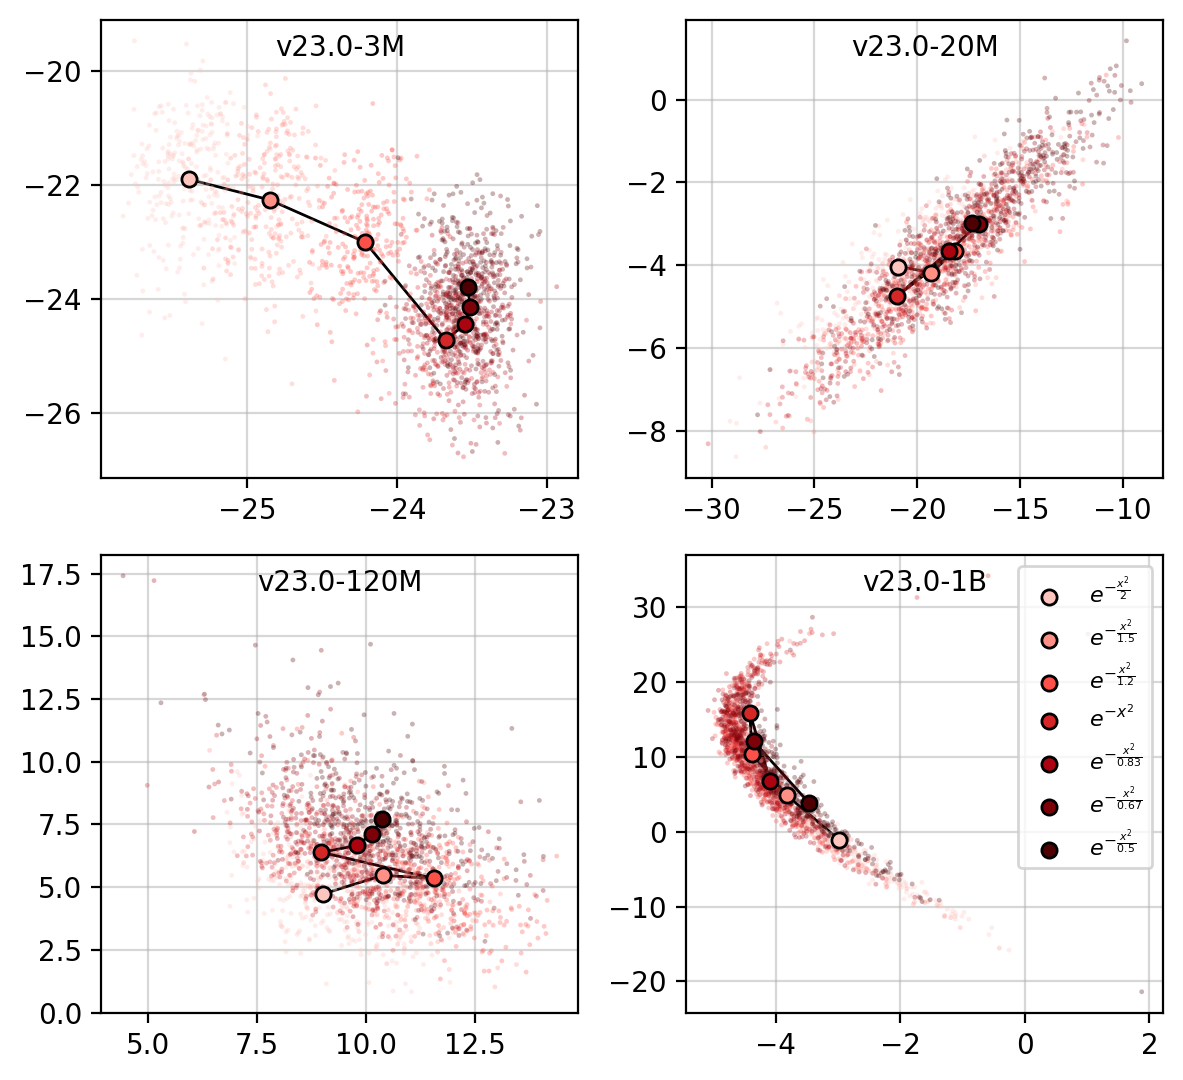

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(6, 5.5), dpi=200)

for i, (model_name, ax) in enumerate(zip(MODEL_NAMES, axes.flatten())):
    ax: plt.Axes
    for color, example in zip(['fcc5bd', 'ff9085', 'fc5048', 'd62728', 'ac0311', '7c0109', '4f0003'], test_examples_sigma['sigma']):

        mean_point = example['embeddings_pca'][model_name].mean(axis=0)
        ax.scatter(
            mean_point[0],
            mean_point[1],
            alpha=1.0,
            color=f'#{color}',
            s=30,
            zorder=5,
            marker='o',
            edgecolors='black',
            linewidths=1,
            label=f"${example['latex']}$"
        )
        ax.scatter(
            example['embeddings_pca'][model_name][:, 0],
            example['embeddings_pca'][model_name][:, 1],
            alpha=0.3,
            color=f'#{color}',
            s=3,
            zorder=4,
            edgecolors='none'
        )

    means = [np.array(example['embeddings_pca'][model_name]).mean(axis=0) for example in test_examples_sigma['sigma']]

    means = np.array(means)
    ax.plot(
        means[:, 0],
        means[:, 1],
        color='black',
        linewidth=1,
        zorder=3,
    )

    ax.annotate(f'{model_name.split("/")[-1]}', xy=(0.5, 0.97), xycoords='axes fraction', va='top', ha='center', fontsize=10)
    ax.grid(alpha=0.5)


axes.flatten()[-1].legend(
    fontsize=8,
)

fig.tight_layout()